# Aviation Disruption Analysis: Iran-US Conflict 2026

This project analyzes the impact of the Iran-US conflict on global aviation using all datasets in the `Aviation_disruption` folder. The workflow covers data cleaning, exploratory analysis, visualization, predictive modeling, and model evaluation (including $R^2$).

## 1. Data Preparation
- Load all CSVs
- Clean and preprocess
- Merge where relevant

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

folder = 'Aviation_disruption/'
airline_losses = pd.read_csv(folder + 'airline_losses_estimate.csv')
airport_disruptions = pd.read_csv(folder + 'airport_disruptions.csv')
airspace_closures = pd.read_csv(folder + 'airspace_closures.csv')
conflict_events = pd.read_csv(folder + 'conflict_events.csv')
flight_cancellations = pd.read_csv(folder + 'flight_cancellations.csv')
flight_reroutes = pd.read_csv(folder + 'flight_reroutes.csv')

## 2. Data Overview & Cleaning
Show info, handle missing values, and create derived columns.

In [8]:
# Clean airline_losses
airline_losses['estimated_daily_loss_usd'] = (
    airline_losses['estimated_daily_loss_usd'].astype(str).str.replace(',', '').astype(float)
)
airline_losses['estimated_loss_million'] = airline_losses['estimated_daily_loss_usd'] / 1e6

# Clean airspace_closures
airspace_closures['closure_start_time'] = pd.to_datetime(airspace_closures['closure_start_time'])
airspace_closures['closure_end_time'] = pd.to_datetime(airspace_closures['closure_end_time'])
airspace_closures['closure_duration_hours'] = (
    (airspace_closures['closure_end_time'] - airspace_closures['closure_start_time']).dt.total_seconds() / 3600
)

# Show info
for name, df in [('Airline Losses', airline_losses), ('Airport Disruptions', airport_disruptions),
                 ('Airspace Closures', airspace_closures), ('Conflict Events', conflict_events),
                 ('Flight Cancellations', flight_cancellations), ('Flight Reroutes', flight_reroutes)]:
    print(f'--- {name} ---')
    print(df.info())
    print(df.head(), '')

--- Airline Losses ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35 entries, 0 to 34
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   airline                   35 non-null     object 
 1   country                   35 non-null     object 
 2   estimated_daily_loss_usd  35 non-null     float64
 3   cancelled_flights         35 non-null     int64  
 4   rerouted_flights          35 non-null     int64  
 5   additional_fuel_cost_usd  35 non-null     int64  
 6   passengers_impacted       35 non-null     int64  
 7   estimated_loss_million    35 non-null     float64
dtypes: float64(2), int64(4), object(2)
memory usage: 2.3+ KB
None
            airline country  estimated_daily_loss_usd  cancelled_flights  \
0          Emirates     UAE                 4200000.0                 18   
1     Qatar Airways   Qatar                 3100000.0                 12   
2    Etihad Airways     UAE   

## 3. Exploratory Data Analysis & Visualization
Visualize key metrics and relationships.

C:\Users\ramya\AppData\Local\Temp\ipykernel_56580\672858216.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top10, y='airline', x='estimated_loss_million', palette='viridis')


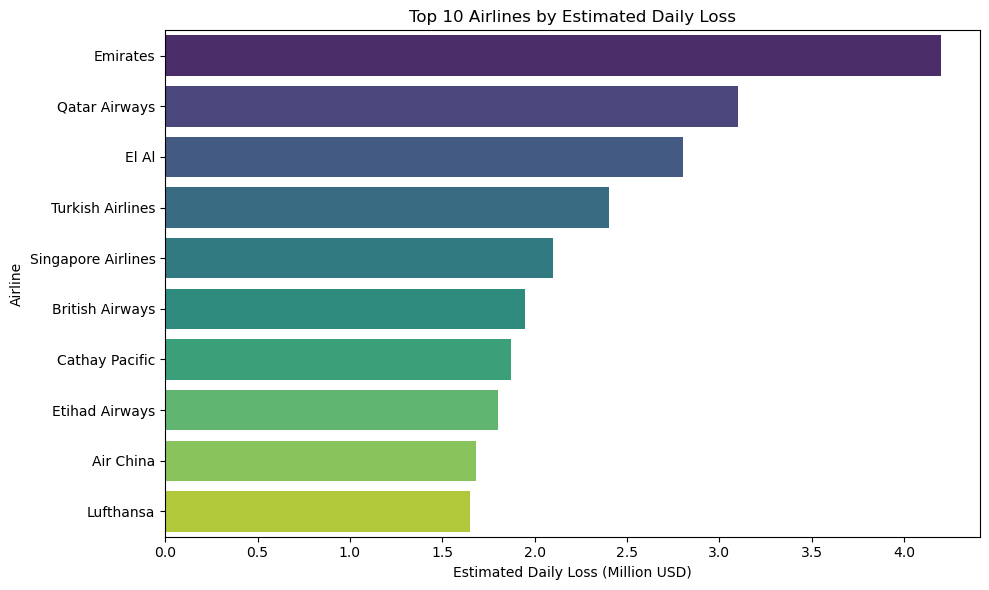

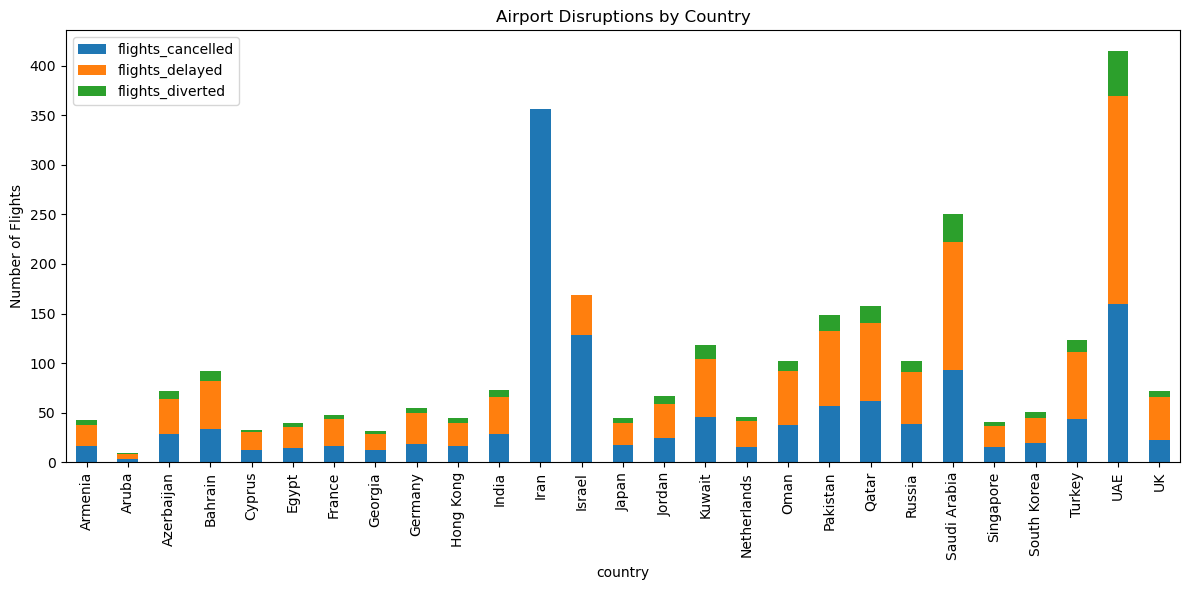

C:\Users\ramya\AppData\Local\Temp\ipykernel_56580\672858216.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top10_closures, y='country', x='closure_duration_hours', palette='mako')


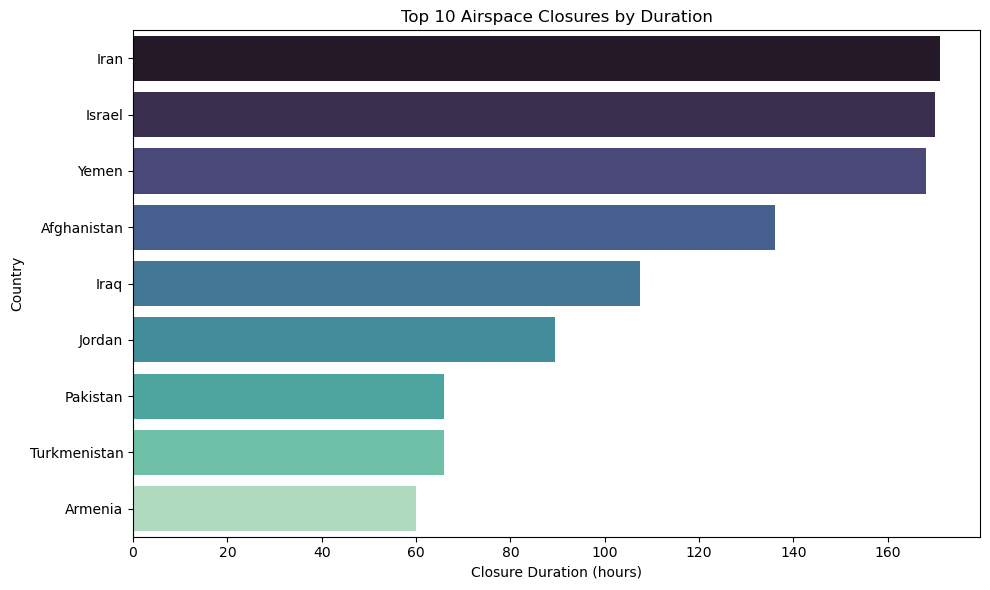

C:\Users\ramya\AppData\Local\Temp\ipykernel_56580\672858216.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cancel_counts.values, y=cancel_counts.index, palette='rocket')


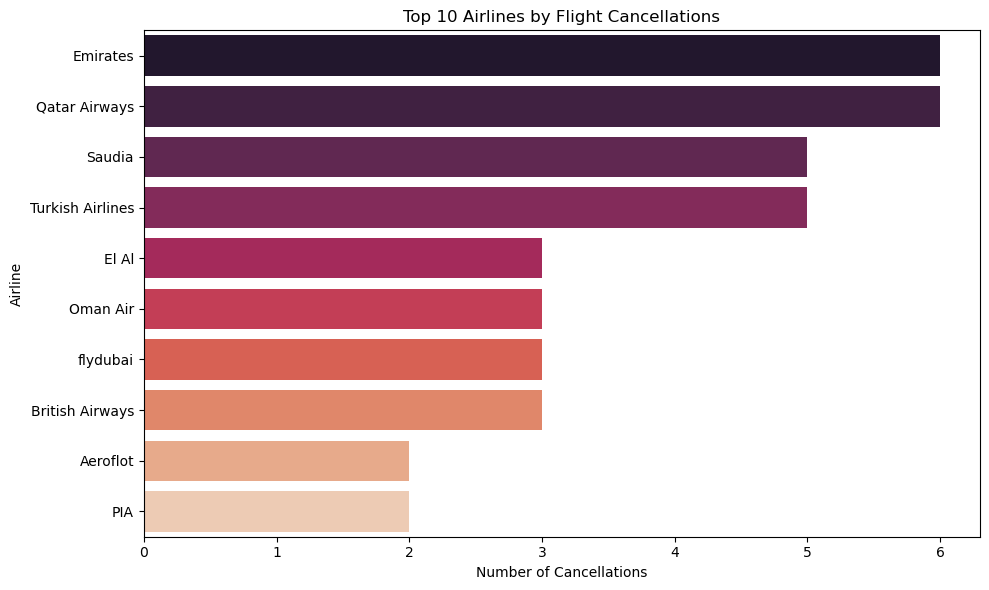

C:\Users\ramya\AppData\Local\Temp\ipykernel_56580\672858216.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=reroute_counts.values, y=reroute_counts.index, palette='crest')


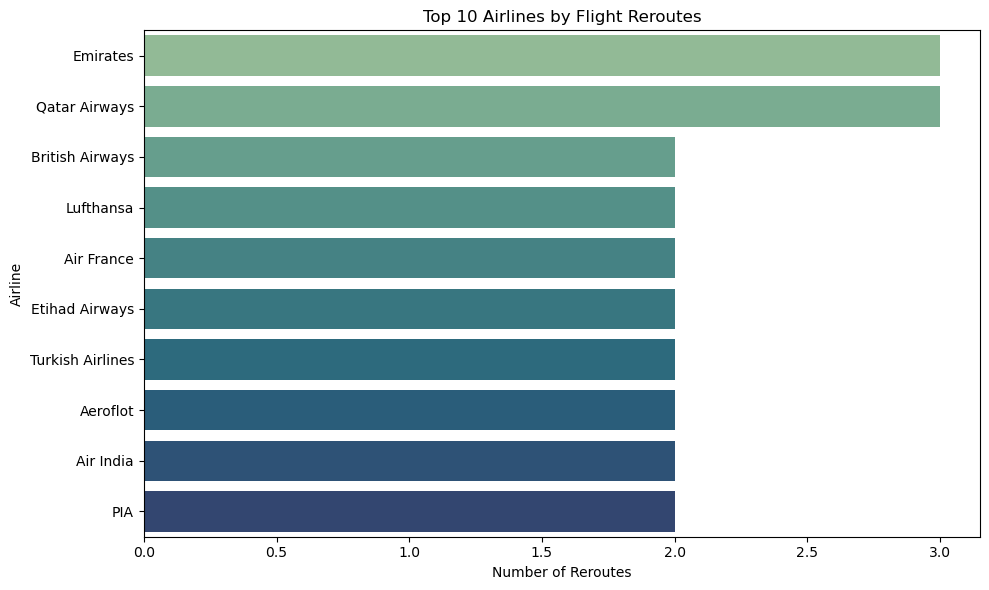

In [9]:
# Top 10 airlines by estimated loss
plt.figure(figsize=(10,6))
top10 = airline_losses.nlargest(10, 'estimated_loss_million')
sns.barplot(data=top10, y='airline', x='estimated_loss_million', palette='viridis')
plt.xlabel('Estimated Daily Loss (Million USD)')
plt.ylabel('Airline')
plt.title('Top 10 Airlines by Estimated Daily Loss')
plt.tight_layout()
plt.show()

# Airport Disruptions: Stacked bar
airport_grouped = airport_disruptions.groupby('country')[['flights_cancelled', 'flights_delayed', 'flights_diverted']].sum().reset_index()
airport_grouped.set_index('country')[['flights_cancelled', 'flights_delayed', 'flights_diverted']].plot(kind='bar', stacked=True, figsize=(12,6))
plt.title('Airport Disruptions by Country')
plt.ylabel('Number of Flights')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Airspace Closures: Top 10 by duration
top10_closures = airspace_closures.nlargest(10, 'closure_duration_hours')
plt.figure(figsize=(10,6))
sns.barplot(data=top10_closures, y='country', x='closure_duration_hours', palette='mako')
plt.xlabel('Closure Duration (hours)')
plt.ylabel('Country')
plt.title('Top 10 Airspace Closures by Duration')
plt.tight_layout()
plt.show()

# Flight Cancellations: Top 10 airlines
cancel_counts = flight_cancellations['airline'].value_counts().head(10)
plt.figure(figsize=(10,6))
sns.barplot(x=cancel_counts.values, y=cancel_counts.index, palette='rocket')
plt.xlabel('Number of Cancellations')
plt.ylabel('Airline')
plt.title('Top 10 Airlines by Flight Cancellations')
plt.tight_layout()
plt.show()

# Flight Reroutes: Top 10 airlines
reroute_counts = flight_reroutes['airline'].value_counts().head(10)
plt.figure(figsize=(10,6))
sns.barplot(x=reroute_counts.values, y=reroute_counts.index, palette='crest')
plt.xlabel('Number of Reroutes')
plt.ylabel('Airline')
plt.title('Top 10 Airlines by Flight Reroutes')
plt.tight_layout()
plt.show()

## 4. Analysis: Correlation & Feature Engineering
Explore relationships between disruptions and losses.

In [10]:
# Example: Merge reroute and cancellation counts with airline_losses
rerouted_counts = flight_reroutes['airline'].value_counts().reset_index()
rerouted_counts.columns = ['airline', 'rerouted_flights']
cancelled_counts = flight_cancellations['airline'].value_counts().reset_index()
cancelled_counts.columns = ['airline', 'cancelled_flights']

airline_merged = pd.merge(airline_losses, rerouted_counts, on='airline', how='left')
airline_merged = pd.merge(airline_merged, cancelled_counts, on='airline', how='left')
airline_merged[['rerouted_flights', 'cancelled_flights']] = airline_merged[['rerouted_flights', 'cancelled_flights']].fillna(0)

# Correlation
print(airline_merged[['estimated_loss_million', 'rerouted_flights', 'cancelled_flights']].corr())

KeyError: "None of [Index(['rerouted_flights', 'cancelled_flights'], dtype='object')] are in the [columns]"

## 5. Predictive Modeling
Predict estimated loss using disruptions as features.

In [ ]:
# Prepare features and target
X = airline_merged[['rerouted_flights', 'cancelled_flights']]
y = airline_merged['estimated_loss_million']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Linear Regression
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Evaluation
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f'R^2: {r2:.3f}')
print(f'RMSE: {rmse:.3f}')

# Plot predicted vs actual
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.xlabel('Actual Estimated Loss (Million USD)')
plt.ylabel('Predicted Estimated Loss (Million USD)')
plt.title('Predicted vs Actual Estimated Loss')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.tight_layout()
plt.show()

## 6. Conclusion
- Summarize key findings from EDA and modeling.
- Discuss model performance and limitations.
- Suggest next steps for deeper analysis or improved modeling.